In [1]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
train_df = pd.read_csv('train_data.csv')
test_df = pd.read_csv('test_data.csv')

train_df['text_lemma'] = train_df['text_lemma'].astype(str)
test_df['text_lemma'] = test_df['text_lemma'].astype(str)

In [3]:
X_train = train_df['text_lemma']
X_test = test_df['text_lemma']

y_train = train_df['label']
y_test = test_df['label']

In [4]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('model', LogisticRegression(max_iter=2000))
])

In [5]:
params = {
    'tfidf__max_features': [5000, 10000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'tfidf__min_df': [3, 5],

    'model__C': [0.1, 1, 5],
    'model__class_weight': [None, 'balanced']
}

grid = GridSearchCV(
    pipeline,
    params,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best params: {'model__C': 5, 'model__class_weight': None, 'tfidf__max_features': 10000, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 1)}
Best CV score: 0.8527798647931754


In [6]:
best_model = grid.best_estimator_

In [7]:
y_pred = best_model.predict(X_test)

In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9447687996263429
Precision: 0.9230498533724341
Recall: 0.7829071734155806
F1: 0.8472222222222222

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97     41333
           1       0.92      0.78      0.85     10051

    accuracy                           0.94     51384
   macro avg       0.94      0.88      0.91     51384
weighted avg       0.94      0.94      0.94     51384



In [9]:
y_proba = best_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9669813087360384


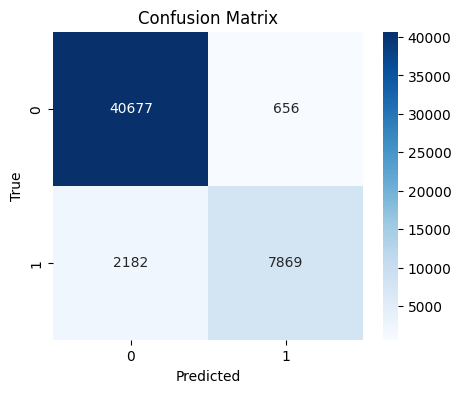

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()